<h2>Imports<h2>

In [1]:
import torch
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# When you execute a code to plot with a simple SHIFT-ENTER, the plot will be shown directly under the code cell
%matplotlib inline

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<h2>Preprocessing<h2>

In [2]:
# Load datasets from sci-kit learn
wine = load_wine()
X = wine.data
y = wine.target

# Split training dataset size to be training and validation dataset, set random state for reproducible result
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=0, stratify=y)

# Scale dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)

<h2>NN Model<h2>

In [3]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size=13, num_classes=3):
        super(SimpleMLP, self).__init__()

        # First hidden layer
        self.fc1 = nn.Linear(input_size, 32)  # 16 → 32
        self.bn1 = nn.BatchNorm1d(32)

        # Second hidden layer
        self.fc2 = nn.Linear(32, 16)  # 8 → 16
        self.bn2 = nn.BatchNorm1d(16)
        # Output layer
        self.fc3 = nn.Linear(16, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # First block: FC → BN → ReLU → Dropout
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Second block: FC → BN → ReLU → Dropout
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Output: FC (no BN, no ReLU, no Dropout)
        x = self.fc3(x)
        return x

# Function to reset model weights for fair comparison
def reset_model(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0)
        elif isinstance(layer, nn.BatchNorm1d):
            nn.init.constant_(layer.weight, 1)
            nn.init.constant_(layer.bias, 0)

criterion = nn.CrossEntropyLoss()

<h2>Adam Training Loop<h2>

In [4]:
# Training hyperparameters
num_epochs = 100
learning_rate = 0.01

# Initialize fresh model
model_adam = SimpleMLP().to(device)
reset_model(model_adam)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=learning_rate, weight_decay=1e-4)

# Tracking lists for Adam
adam_train_losses = []
adam_train_accs = []
adam_val_losses = []
adam_val_accs = []

for epoch in range(num_epochs):
    # Training
    model_adam.train()
    outputs = model_adam(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer_adam.zero_grad()
    loss.backward()
    optimizer_adam.step()

    # Calculate training accuracy
    _, predicted = torch.max(outputs, 1)
    train_acc = 100 * (predicted == y_train_tensor).sum().item() / len(y_train_tensor)

    # Validation
    model_adam.eval()
    with torch.no_grad():
        val_outputs = model_adam(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        _, val_predicted = torch.max(val_outputs, 1)
        val_acc = 100 * (val_predicted == y_val_tensor).sum().item() / len(y_val_tensor)

    # Store metrics
    adam_train_losses.append(loss.item())
    adam_train_accs.append(train_acc)
    adam_val_losses.append(val_loss.item())
    adam_val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Adam - Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {loss.item():.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.2f}%")

print(f"Adam Best Val Acc: {max(adam_val_accs):.2f}%")

Adam - Epoch [5/100] Train Loss: 1.1482, Train Acc: 59.86% | Val Loss: 0.3770, Val Acc: 80.56%
Adam - Epoch [10/100] Train Loss: 0.3264, Train Acc: 91.55% | Val Loss: 0.1114, Val Acc: 97.22%
Adam - Epoch [15/100] Train Loss: 0.1305, Train Acc: 95.77% | Val Loss: 0.0514, Val Acc: 100.00%
Adam - Epoch [20/100] Train Loss: 0.1385, Train Acc: 94.37% | Val Loss: 0.0313, Val Acc: 100.00%
Adam - Epoch [25/100] Train Loss: 0.1282, Train Acc: 96.48% | Val Loss: 0.0236, Val Acc: 100.00%
Adam - Epoch [30/100] Train Loss: 0.0838, Train Acc: 97.89% | Val Loss: 0.0221, Val Acc: 100.00%
Adam - Epoch [35/100] Train Loss: 0.1020, Train Acc: 97.89% | Val Loss: 0.0191, Val Acc: 100.00%
Adam - Epoch [40/100] Train Loss: 0.0551, Train Acc: 97.89% | Val Loss: 0.0146, Val Acc: 100.00%
Adam - Epoch [45/100] Train Loss: 0.0735, Train Acc: 98.59% | Val Loss: 0.0107, Val Acc: 100.00%
Adam - Epoch [50/100] Train Loss: 0.0495, Train Acc: 98.59% | Val Loss: 0.0096, Val Acc: 100.00%
Adam - Epoch [55/100] Train Loss:

<h2>ES Training Loop<h2>

In [5]:
# Extract all model weights into a single 1D vector
def get_weights_as_vector(model):
    params = []
    for param in model.parameters():
        params.append(param.data.view(-1))
    return torch.cat(params)

# Set model weights from a 1D vector
def set_weights_from_vector(model, weight_vector):
    idx = 0
    for param in model.parameters():
        param_size = param.numel()
        param.data.copy_(weight_vector[idx:idx + param_size].view(param.shape))
        idx += param_size

# Evaluate model accuracy as fitness
def evaluate_fitness(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        outputs = model(X_val)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_val).sum().item() / len(y_val)
    return accuracy

# Different random seeds for each run
seeds = [42, 123, 456, 789, 101112]

# Store results from all runs
all_es_train_losses = []
all_es_train_accs = []
all_es_val_losses = []
all_es_val_accs = []
all_es_best_fitness = []
all_es_best_val_accs = []

for run, seed in enumerate(seeds):

    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Create fresh model for ES
    model_es = SimpleMLP().to(device)
    reset_model(model_es)

    # ES Hyperparameters
    population_size = 30
    sigma = 0.1
    num_generations = 100

    # Tracking lists for this run
    es_train_losses = []
    es_train_accs = []
    es_val_losses = []
    es_val_accs = []
    es_best_fitness = []

    # Get initial parent weights
    parent_weights = get_weights_as_vector(model_es)
    param_count = len(parent_weights)

    for generation in range(num_generations):
        # Create population by adding noise to parent weights
        population_weights = []
        population_fitness = []

        for i in range(population_size):
            noise = torch.randn(param_count).to(device) * sigma
            child_weights = parent_weights + noise
            population_weights.append(child_weights)

        # Evaluate population
        for child_weights in population_weights:
            set_weights_from_vector(model_es, child_weights)
            fitness = evaluate_fitness(model_es, X_val_tensor, y_val_tensor)
            population_fitness.append(fitness)

        # Pick best performing models
        # Convert to tensor for easier manipulation
        population_fitness = torch.tensor(population_fitness)

        # Select top performers (top 25% or at least 1)
        top_k = max(1, population_size // 4)
        top_indices = torch.argsort(population_fitness, descending=True)[:top_k]

        # Weighted average based on fitness for new parent
        new_parent = torch.zeros(param_count).to(device)
        total_fitness = 0
        for idx in top_indices:
            fitness = population_fitness[idx]
            new_parent += population_weights[idx] * fitness
            total_fitness += fitness

        new_parent /= total_fitness
        parent_weights = new_parent

        # Evaluate parent model
        # Set model to parent weights and evaluate
        set_weights_from_vector(model_es, parent_weights)

        model_es.eval()
        with torch.no_grad():
            # Training metrics
            train_outputs = model_es(X_train_tensor)
            train_loss = criterion(train_outputs, y_train_tensor)
            _, train_predicted = torch.max(train_outputs, 1)
            train_acc = 100 * (train_predicted == y_train_tensor).sum().item() / len(y_train_tensor)

            # Validation metrics
            val_outputs = model_es(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
            _, val_predicted = torch.max(val_outputs, 1)
            val_acc = 100 * (val_predicted == y_val_tensor).sum().item() / len(y_val_tensor)

        # Store metrics
        es_train_losses.append(train_loss.item())
        es_train_accs.append(train_acc)
        es_val_losses.append(val_loss.item())
        es_val_accs.append(val_acc)
        es_best_fitness.append(population_fitness.max().item())

        if (generation + 1) % 20 == 0:
            print(f"  Gen [{generation+1}/{num_generations}] "
                  f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%, "
                  f"Best Fitness: {population_fitness.max().item():.4f}")

    best_val_acc = max(es_val_accs)
    all_es_best_val_accs.append(best_val_acc)
    print(f"\n  Best Validation Accuracy: {best_val_acc:.2f}%")

    # Store this run's data for averaging
    all_es_train_losses.append(es_train_losses)
    all_es_train_accs.append(es_train_accs)
    all_es_val_losses.append(es_val_losses)
    all_es_val_accs.append(es_val_accs)
    all_es_best_fitness.append(es_best_fitness)

# Convert to numpy arrays for easy averaging
all_es_val_accs_np = np.array(all_es_val_accs)
all_es_train_accs_np = np.array(all_es_train_accs)
all_es_val_losses_np = np.array(all_es_val_losses)
all_es_train_losses_np = np.array(all_es_train_losses)

# Calculate mean and std across runs for each generation
mean_val_accs = np.mean(all_es_val_accs_np, axis=0)
std_val_accs = np.std(all_es_val_accs_np, axis=0)
mean_train_accs = np.mean(all_es_train_accs_np, axis=0)
std_train_accs = np.std(all_es_train_accs_np, axis=0)
mean_val_losses = np.mean(all_es_val_losses_np, axis=0)
std_val_losses = np.std(all_es_val_losses_np, axis=0)
mean_train_losses = np.mean(all_es_train_losses_np, axis=0)
std_train_losses = np.std(all_es_train_losses_np, axis=0)

# Summary statistics
print(f"\nBest Validation Accuracies per run: {all_es_best_val_accs}")
print(f"Mean Best Validation Accuracy: {np.mean(all_es_best_val_accs):.2f}%")
print(f"Std Dev Best Validation Accuracy: {np.std(all_es_best_val_accs):.2f}%")
print(f"Min Best Validation Accuracy: {min(all_es_best_val_accs):.2f}%")
print(f"Max Best Validation Accuracy: {max(all_es_best_val_accs):.2f}%")

# Final generation averages
print(f"\nFinal Generation (Gen {num_generations}) Averages:")
print(f"  Mean Train Acc: {mean_train_accs[-1]:.2f}% ± {std_train_accs[-1]:.2f}")
print(f"  Mean Val Acc:   {mean_val_accs[-1]:.2f}% ± {std_val_accs[-1]:.2f}")
print(f"  Mean Train Loss: {mean_train_losses[-1]:.4f} ± {std_train_losses[-1]:.4f}")
print(f"  Mean Val Loss:   {mean_val_losses[-1]:.4f} ± {std_val_losses[-1]:.4f}")

  Gen [20/100] Train Acc: 93.66% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [40/100] Train Acc: 90.14% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [60/100] Train Acc: 93.66% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [80/100] Train Acc: 89.44% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [100/100] Train Acc: 91.55% | Val Acc: 100.00%, Best Fitness: 1.0000

  Best Validation Accuracy: 100.00%
  Gen [20/100] Train Acc: 89.44% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [40/100] Train Acc: 90.14% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [60/100] Train Acc: 88.03% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [80/100] Train Acc: 89.44% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [100/100] Train Acc: 83.80% | Val Acc: 100.00%, Best Fitness: 1.0000

  Best Validation Accuracy: 100.00%
  Gen [20/100] Train Acc: 87.32% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [40/100] Train Acc: 92.25% | Val Acc: 100.00%, Best Fitness: 1.0000
  Gen [60/100] Train Acc: 91.55% | V

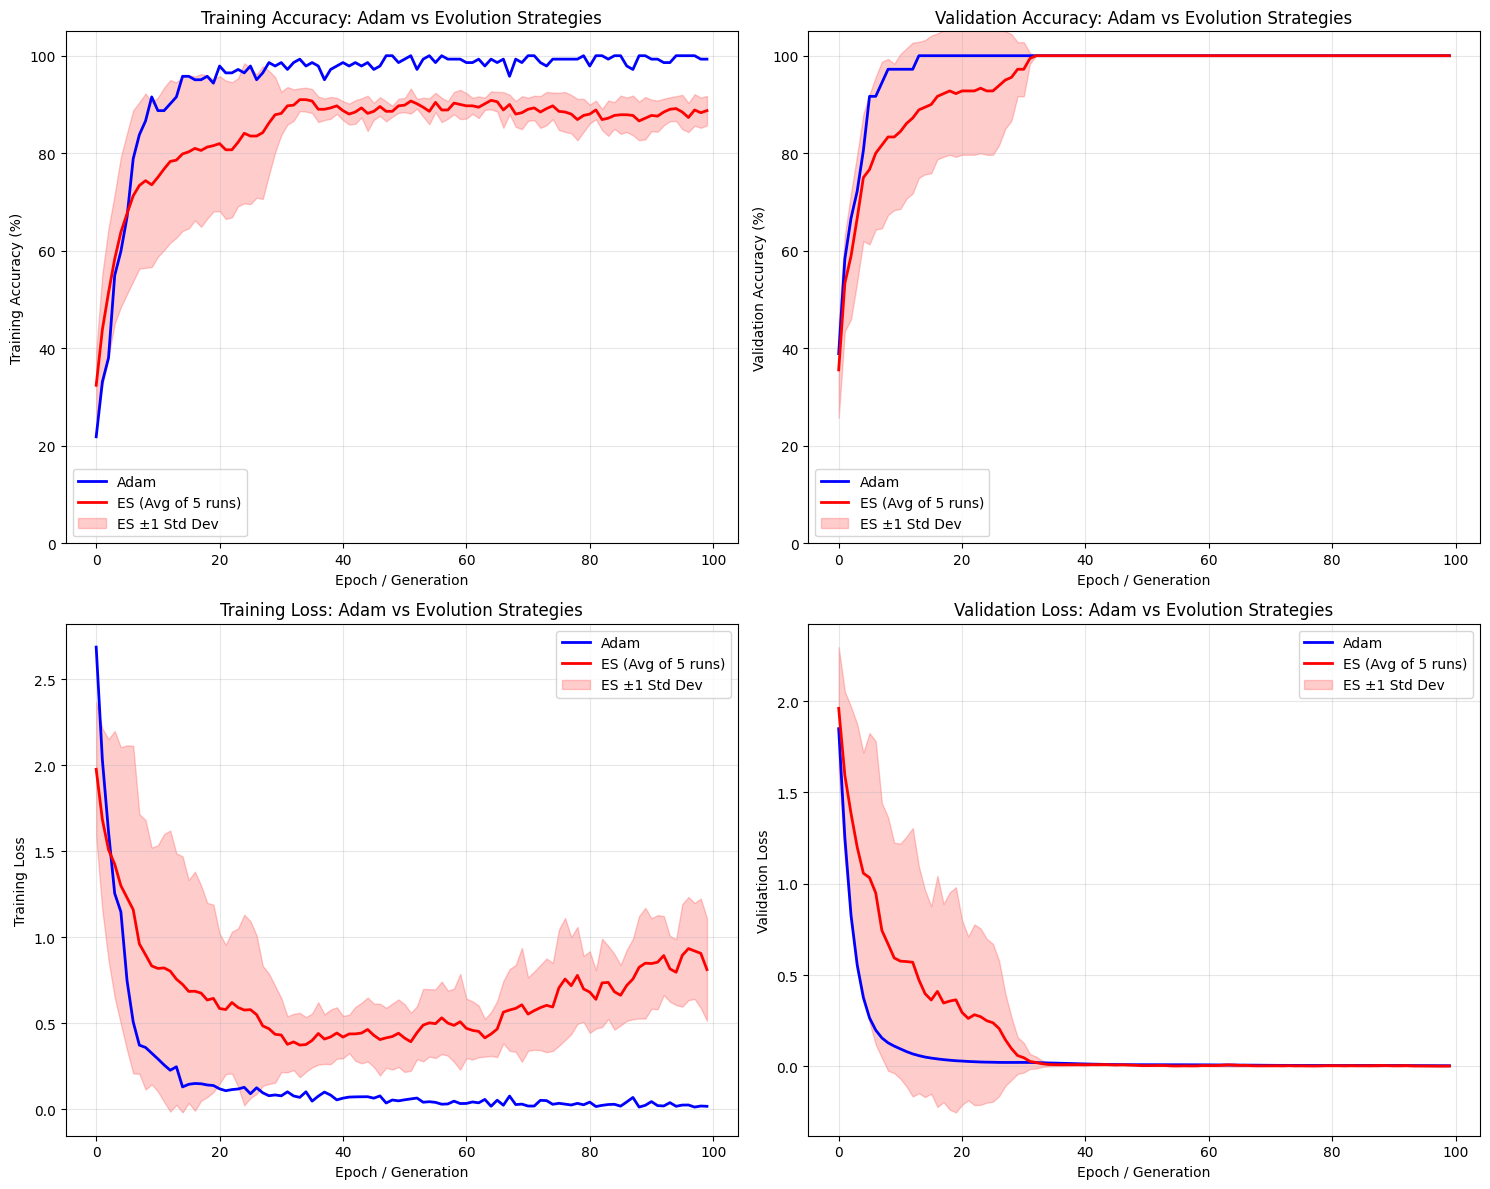

In [6]:
# Create figure with 2x2 subplots (4 plots total)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training Accuracy Comparison (Top-Left)
axes[0, 0].plot(adam_train_accs, label='Adam', linewidth=2, color='blue')
axes[0, 0].plot(mean_train_accs, label='ES (Avg of 5 runs)', linewidth=2, color='red')
# Add error bands for ES
axes[0, 0].fill_between(range(len(mean_train_accs)),
                         mean_train_accs - std_train_accs,
                         mean_train_accs + std_train_accs,
                         alpha=0.2, color='red', label='ES ±1 Std Dev')
axes[0, 0].set_xlabel('Epoch / Generation')
axes[0, 0].set_ylabel('Training Accuracy (%)')
axes[0, 0].set_title('Training Accuracy: Adam vs Evolution Strategies')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 105])

# Plot 2: Validation Accuracy Comparison (Top-Right)
axes[0, 1].plot(adam_val_accs, label='Adam', linewidth=2, color='blue')
axes[0, 1].plot(mean_val_accs, label='ES (Avg of 5 runs)', linewidth=2, color='red')
# Add error bands for ES
axes[0, 1].fill_between(range(len(mean_val_accs)),
                         mean_val_accs - std_val_accs,
                         mean_val_accs + std_val_accs,
                         alpha=0.2, color='red', label='ES ±1 Std Dev')
axes[0, 1].set_xlabel('Epoch / Generation')
axes[0, 1].set_ylabel('Validation Accuracy (%)')
axes[0, 1].set_title('Validation Accuracy: Adam vs Evolution Strategies')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 105])

# Plot 3: Training Loss Comparison (Bottom-Left)
axes[1, 0].plot(adam_train_losses, label='Adam', linewidth=2, color='blue')
axes[1, 0].plot(mean_train_losses, label='ES (Avg of 5 runs)', linewidth=2, color='red')
# Add error bands for ES
axes[1, 0].fill_between(range(len(mean_train_losses)),
                         mean_train_losses - std_train_losses,
                         mean_train_losses + std_train_losses,
                         alpha=0.2, color='red', label='ES ±1 Std Dev')
axes[1, 0].set_xlabel('Epoch / Generation')
axes[1, 0].set_ylabel('Training Loss')
axes[1, 0].set_title('Training Loss: Adam vs Evolution Strategies')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Validation Loss Comparison (Bottom-Right)
axes[1, 1].plot(adam_val_losses, label='Adam', linewidth=2, color='blue')
axes[1, 1].plot(mean_val_losses, label='ES (Avg of 5 runs)', linewidth=2, color='red')
# Add error bands for ES
axes[1, 1].fill_between(range(len(mean_val_losses)),
                         mean_val_losses - std_val_losses,
                         mean_val_losses + std_val_losses,
                         alpha=0.2, color='red', label='ES ±1 Std Dev')
axes[1, 1].set_xlabel('Epoch / Generation')
axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].set_title('Validation Loss: Adam vs Evolution Strategies')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

In [7]:
# ==================== SUMMARY TABLE ====================
print("\n" + "=" * 85)
print("SUMMARY RESULTS")
print("=" * 85)
print(f"{'Metric':<35} {'Adam':<20} {'Evolution Strategies (5 runs)':<30}")
print("-" * 85)

# Best Validation Accuracy
es_best_mean = np.mean(all_es_best_val_accs)
es_best_std = np.std(all_es_best_val_accs)
print(f"{'Best Validation Accuracy (%)':<35} {max(adam_val_accs):<20.2f} {es_best_mean:<5.2f} ± {es_best_std:.2f}")

# Final Validation Accuracy
print(f"{'Final Validation Accuracy (%)':<35} {adam_val_accs[-1]:<20.2f} {mean_val_accs[-1]:<5.2f} ± {std_val_accs[-1]:.2f}")

# Best Training Accuracy
print(f"{'Best Training Accuracy (%)':<35} {max(adam_train_accs):<20.2f} {max(mean_train_accs):<25.2f}")

# Final Training Accuracy
print(f"{'Final Training Accuracy (%)':<35} {adam_train_accs[-1]:<20.2f} {mean_train_accs[-1]:<25.2f}")

# Convergence speed
def epochs_to_reach(accuracies, target=90):
    for i, acc in enumerate(accuracies):
        if acc >= target:
            return i + 1
    return len(accuracies)

adam_convergence = epochs_to_reach(adam_val_accs, 90)
es_convergence = epochs_to_reach(mean_val_accs, 90)

print(f"{'Convergence Speed (to 90% val acc)':<35} {adam_convergence:<20} {es_convergence:<25}")
print("=" * 85)


SUMMARY RESULTS
Metric                              Adam                 Evolution Strategies (5 runs) 
-------------------------------------------------------------------------------------
Best Validation Accuracy (%)        100.00               100.00 ± 0.00
Final Validation Accuracy (%)       100.00               100.00 ± 0.00
Best Training Accuracy (%)          100.00               90.99                    
Final Training Accuracy (%)         99.30                88.73                    
Convergence Speed (to 90% val acc)  6                    16                       
